<a href="https://colab.research.google.com/github/HamzaEric/Heart_Diagnosis_MLP/blob/main/Notebooks/Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Perceptron For Binary Classification

```text
  x₁        x₂  
   │        │  
   ▼        ▼  
 [w₁]     [w₂]    →   Weighted sum: z = w₁·x₁ + w₂·x₂ + b  
   \        /  
    ▼      ▼  
  Add bias (b)  
        ↓  
Step Activation  
        ↓  
Output: ŷ ∈ {0,1}

```

**Key Intuition**

The perceptron is learning to find a **line** that best separates the two classes.

That line is defined by:

$$
\mathbf{w}^\top \mathbf{x} + b = 0
$$

This is the **decision boundary**.

- If a point lies **above** the line → Class 1
- If a point lies **below** the line → Class 0

**However,**

- The perceptron **can only learn linearly separable data**.
- If the data is not linearly separable, the perceptron will **not converge** — it will keep updating weights forever!

---

# Math Flow

# Input Vector ($x$)

$$x = \begin{bmatrix} x_1 \\ x_2 \\ x_3 \\ x_4 \\ x_5 \\ x_6 \\ x_7 \\ x_8 \end{bmatrix} = \begin{bmatrix} \text{Age} \\ \text{Resting BP} \\ \text{Cholesterol} \\ \text{Blood Sugar} \\ \text{Resting ECG} \\ \text{Max Heart Rate} \\ \text{Angina} \\ \text{ST Peak} \end{bmatrix}$$

# Weight Vector ($w$)

$$w = \begin{bmatrix} w_1 \\ w_2 \\ w_3 \\ w_4 \\ w_5 \\ w_6 \\ w_7 \\ w_8 \end{bmatrix}$$

# The Transpose

$$w^\top x = \begin{bmatrix} w_1 & w_2 & w_3 & w_4 & w_5 & w_6 & w_7 & w_8 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \\ x_4 \\ x_5 \\ x_6 \\ x_7 \\ x_8 \end{bmatrix}$$

# Matrix Multiplication

$$w^\top x = (w_1 \cdot x_1) + (w_2 \cdot x_2) + (w_3 \cdot x_3) + (w_4 \cdot x_4) + (w_5 \cdot x_5) + (w_6 \cdot x_6) + (w_7 \cdot x_7) + (w_8 \cdot x_8)$$

# The Bias

$$z = w^\top x + b$$




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df['num'].value_counts()

,count
num,
0,164
1,55
2,36
3,35
4,13


In [ ]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df['label'] = (df['num'] > 0).astype(int)

X_real = df[['thalach', 'oldpeak']].values
y_real = df['label'].values

print("X_real shape:", X_real.shape)
print("y_real class distribution:", np.bincount(y_real))

X_real shape: (303, 2)
y_real class distribution: [164 139]


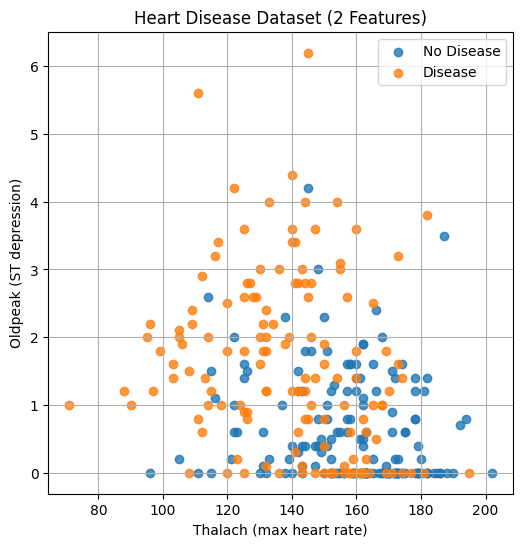

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X_real[y_real==0, 0], X_real[y_real==0, 1], label='No Disease', alpha=0.8)
plt.scatter(X_real[y_real==1, 0], X_real[y_real==1, 1], label='Disease', alpha=0.8)

plt.xlabel("Thalach (max heart rate)")
plt.ylabel("Oldpeak (ST depression)")
plt.title("Heart Disease Dataset (2 Features)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
w_real = np.random.randn(X_real.shape[1])  # shape (2,)
b_real = np.random.randn()


# Training settings
lr = 0.1
epochs = 50
errors_real = []

# Step function
def step(z): return 1 if z >= 0 else 0

# Training loop
for epoch in range(epochs):
    total_errors = 0
    for xi, yi in zip(X_real, y_real):
        z = np.dot(w_real, xi) + b_real
        y_hat = step(z)

        error = yi - y_hat
        if error != 0:
            w_real += lr * error * xi
            b_real += lr * error
            total_errors += 1
    errors_real.append(total_errors)

print("Final weights:", w_real)
print("Final bias:", b_real)

Final weights: [ -8.88703071 240.85769881]
Final bias: 38.71192337068453


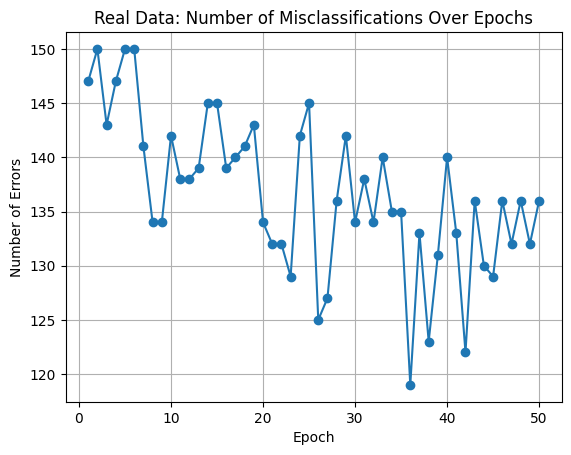

In [ ]:
plt.plot(range(1, epochs+1), errors_real, marker='o')
plt.title('Real Data: Number of Misclassifications Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Number of Errors')
plt.grid(True)
plt.show()

In [ ]:
def step_function(z):
    return np.where(z >= 0, 1, 0)

z = np.dot(X_real, w_real) + b_real
y_pred = step_function(z)

correct_predictions = np.sum(y_pred == y_real)
total_predictions = len(y_real)
expected_accuracy = correct_predictions / total_predictions

print(f"✅ Expected Accuracy: {expected_accuracy:.2f}")

✅ Expected Accuracy: 0.55


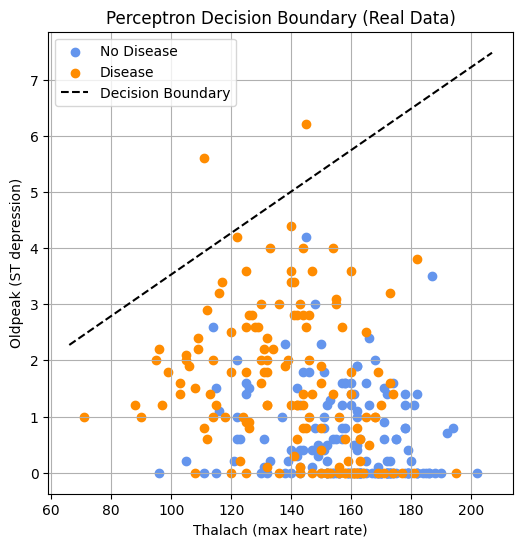

In [ ]:
w1, w2 = w_real[0], w_real[1]
b = b_real


x1_vals = np.linspace(X_real[:, 0].min() - 5, X_real[:, 0].max() + 5, 100)
x2_vals = (-b - w1 * x1_vals) / w2

plt.figure(figsize=(6,6))
plt.scatter(X_real[y_real==0][:, 0], X_real[y_real==0][:, 1], color='cornflowerblue', label='No Disease')
plt.scatter(X_real[y_real==1][:, 0], X_real[y_real==1][:, 1], color='darkorange', label='Disease')

# Plot the decision boundary
plt.plot(x1_vals, x2_vals, color='black', linestyle='--', label='Decision Boundary')

plt.xlabel('Thalach (max heart rate)')
plt.ylabel('Oldpeak (ST depression)')
plt.title('Perceptron Decision Boundary (Real Data)')
plt.legend()
plt.grid(True)
plt.show()

# Insights
The Data is Linearly Inseparable


Needs More Hidden Layers And An Activation Function